# Customer Churn Model

Churn is the percentage of customers who stop doing business with a company over a period of time.
Churn is an important metric for businesses as it directly impacts revenue, growth, and customer retention.

Businesses that understand customer churn are able to properly analyze it for pattern identification, making it easier to develop strategic plans to avoid customer attrition.

Customer churn costs companies millions annually. This project builds a machine learning model to identify at-risk customers early, enabling targeted retention strategies.



In a world where customer acquisition is practically a herculean feat, it is important to ensure that customer churn is properly tracked and analyzed.

This project addresses the question: given a customer's credit score, account balance, number of products, and activity status, can we predict whether they will exit the bank? The goal is to shift from reactive to proactive retention.

## About Dataset

The dataset was gotten from Kaggle Churn Modeling dataset.
https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling/data

It has 14 columns, and contains data concerning customers' of a big international bank.

| Column | Description |
|---|---|
| CreditScore | Customer's credit score |
| Geography | Country of the customer |
| Age | Customer's age |
| Tenure | Years with the bank |
| Balance | Account balance |
| NumOfProducts | Number of bank products used |
| HasCrCard | Whether the customer has a credit card |
| IsActiveMember | Whether the customer is active |
| EstimatedSalary | Estimated annual salary |
| Exited | 1 = churned, 0 = stayed |


### Import Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv('Churn_Modelling.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Dropping Columns

To properly predict churn from this dataset, it is important to remove non-predictive columns, namely, <b>RowNumber</b>, <b>CustomerId</b>, and <b>Surname</b>. These columns are either arbitrary identifiers or personally identifiable information that carry no statistical relationship with churn behavior, and including them risks introducing noise without any benefit to the model.


<b>RowNumber</b> and <b>CustomerId</b> are arbitrary identifiers with no relationship to churn. <b>Surname</b>, while potentially linkable to demographics, introduces ethical concerns around PII and adds no reliable predictive signal.

In [ ]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

### Visualizations

To properly understand the dataset and draw meaningful insights from it, I decided to visualize the data using different charts and plots. These visualizations help reveal patterns, trends, relationships between variables, and customer behaviors related to churn

### Churn Distribution Bar Chart

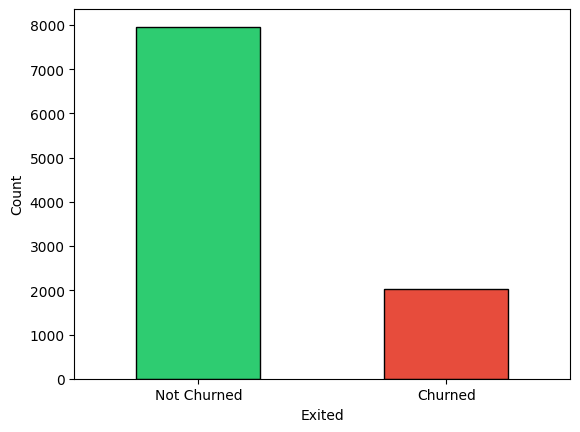

In [ ]:
df['Exited'].value_counts().plot(kind='bar')

df['Exited'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Churned', 'Churned'], rotation = 360)
plt.show()

*Figure 1: Churn Distribution showing class imbalance, with approximately 80% of customers not churned (0) and 20% churned (1).*

*The imbalance will be addressed when building the model.*

### Churn Rate by Number of Products

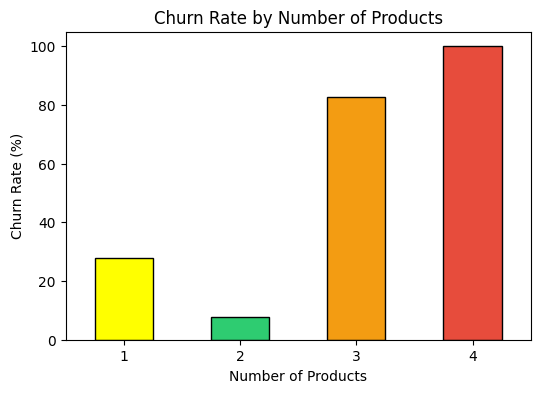

In [ ]:
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean() * 100

plt.figure(figsize=(6, 4))
churn_by_products.plot(kind='bar', color=['#ffff00', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()


*Figure 2: The data shows that the more products a customer buys, the more likely they are to churn. Customers with 3 or more products show higher churn rates, peaking at nearly a 100% for more products.*

### Churn Rate by Activity

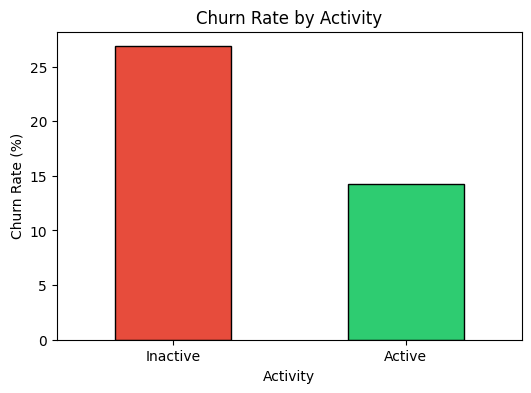

In [ ]:
churn_by_activity = df.groupby('IsActiveMember')['Exited'].mean() * 100

plt.figure(figsize=(6, 4))
churn_by_activity.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Churn Rate by Activity')
plt.xlabel('Activity')
plt.ylabel('Churn Rate (%)')
plt.xticks([0, 1], ['Inactive', 'Active'], rotation = 360)
plt.show()


*Figure 3: This plot shows that inactive customers have higher churn rates that active customers*

### Churn Rate by Age

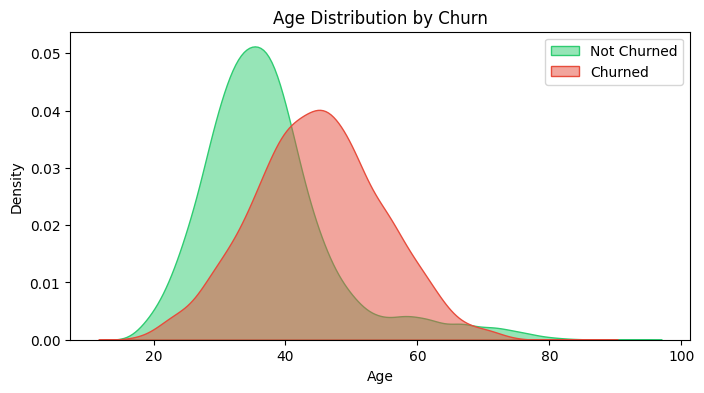

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df[df['Exited'] == 0]['Age'], label='Not Churned', fill=True, color='#2ecc71', alpha=0.5)
sns.kdeplot(data=df[df['Exited'] == 1]['Age'], label='Churned', fill=True, color='#e74c3c', alpha=0.5)
plt.title('Age Distribution by Churn')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

*Figure 4: Younger customers (under 35) are less likely to churn, while older customers (45+) represent the majority of churned customers, suggesting age is a meaningful predictor of churn behavior.*

### Churn Rate by Geography

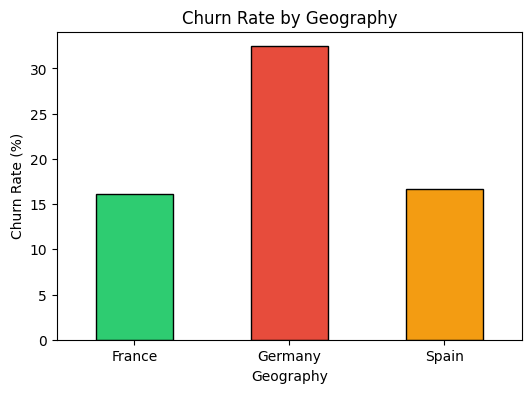

In [ ]:
churn_by_geography = df.groupby('Geography')['Exited'].mean() * 100

plt.figure(figsize=(6, 4))
churn_by_geography.plot(kind='bar', color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black')
plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()


*Figure 5: From the plot, it is clear that customers in Germany have a higher churn rate than customers in France and Spain*

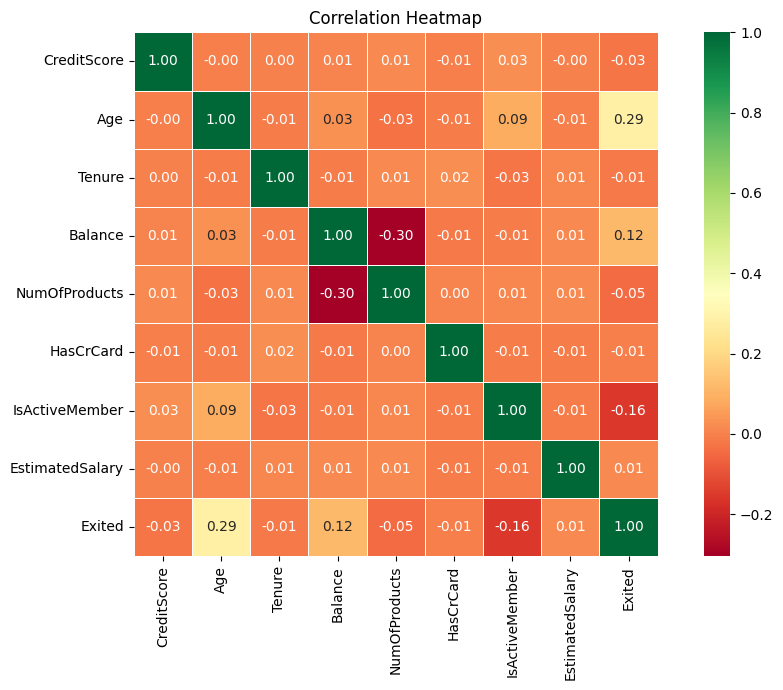

In [ ]:
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include='number').columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

*Figure 6: Correlation heatmap of all numeric features. Age shows the strongest positive correlation with churn (0.29), while IsActiveMember shows the strongest negative correlation (-0.16). Most features exhibit weak linear relationships with churn, highlighting the need for a multi-feature model.*

### Label Encoding and One-Hot Encoding

This is used to convert non-numeric (categorical) columns into numeric values so that machine learning models can understand and process them.

In [ ]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns = ['Geography'], drop_first=True)

In [ ]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited']

### Training and Testing Set

The dataframe is split 80/20 into the **Training set** and **Testing set**. The Training set is for training the model, and the Testing set to test against the predictions made by the model.

A random state sets a fixed random seed so your results stay the same every time you run the code.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Feature Scaling

This is crucial so as to ensure all features are on a similar scale, which improves the performance and learning stability of the model.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Building

The model is built using the RandomForest Classifier. This is because it can handle complex patterns, and also identifies important features.

In [ ]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight = 'balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

The imbalance in our dataset is addresed. The model will now pay more attention to churners.

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)


In [ ]:
print(conf_matrix)
print(class_report)
print(accuracy)

[[1552   55]
 [ 213  180]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

0.866


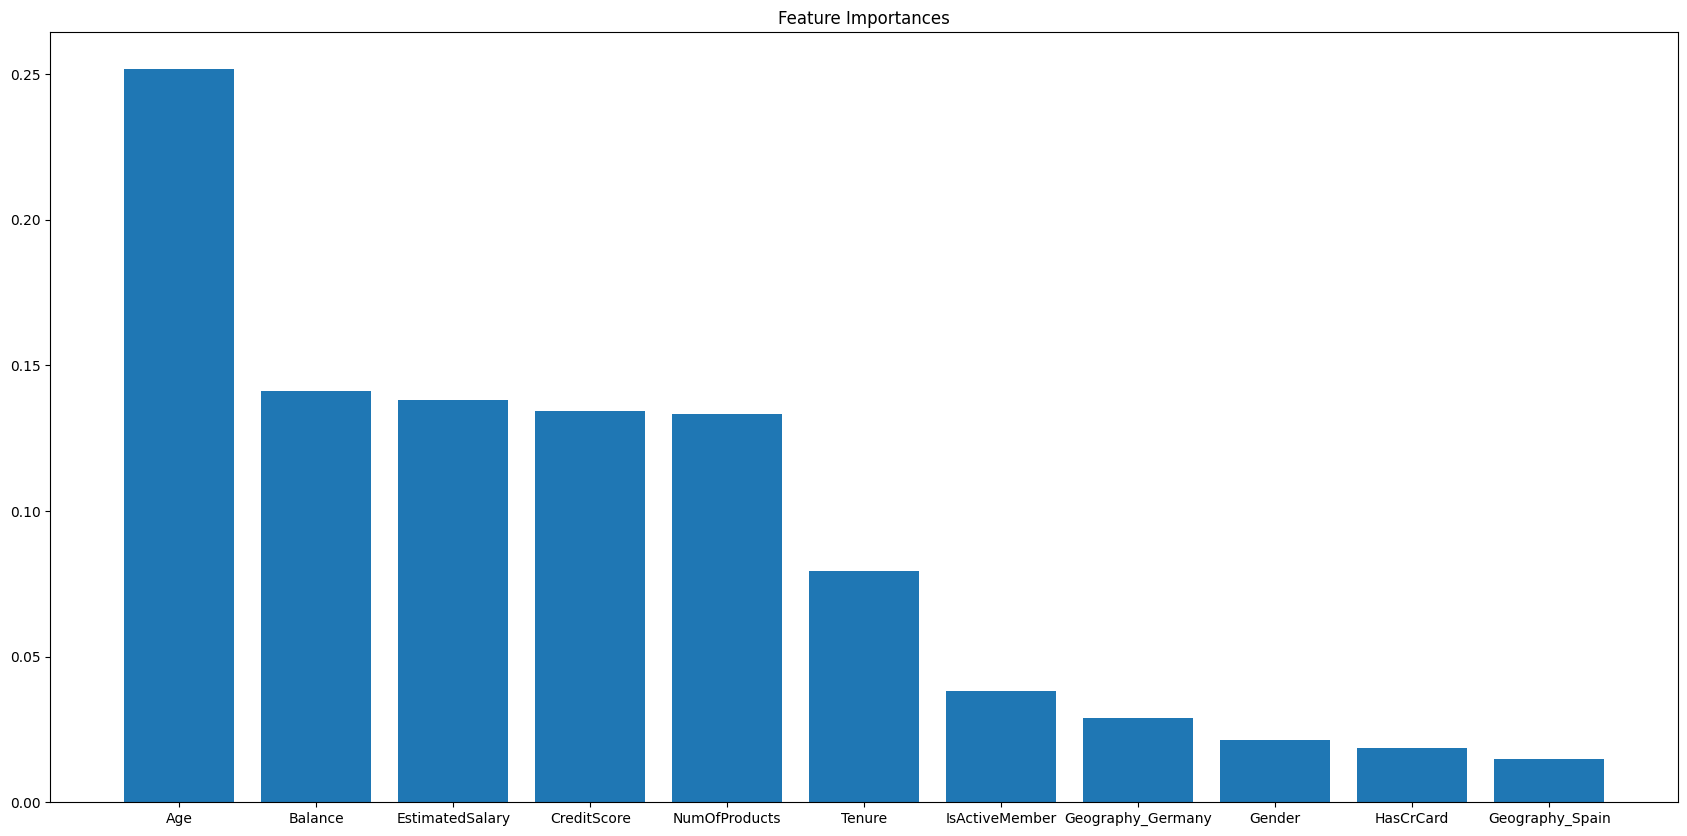

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', "Geography_Spain"]
names = [features[i] for i in indices]

plt.figure(figsize=(21, 10))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), names)
plt.title("Feature Importances")
plt.show()

### Conclusions and Business Insights

The model achieved an accuracy score of 0.866. Feature importance analysis revealed that Age, EstimatedSalary, and CreditScore were the strongest predictors of churn.

The data also shows:
*   Older customers (45+) are more likely to churn, so retention programs specifically catering to older people should be curated.
*   Inactive customers should be paid more attention to, as inactivity naturally leads to attrition.
*   German customers have the highest churn rate, so it is worth investigating bank service in that region


